Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [26]:
# Updated dummy data to include columns required for preprocessing
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Score': [85, 92, 78, 65, 88],
    'StudyHours': [10, 15, 8, 5, 12],
    'Attendance': [95, 100, 80, 60, 90],
    'PreviousScore': [80, 90, 75, 70, 85],
    'Pass': [1, 1, 1, 0, 1]
}
pd.DataFrame(data).to_csv("student_data.csv", index=False)

df = pd.read_csv("student_data.csv")
print(df.head())

      Name  Score  StudyHours  Attendance  PreviousScore  Pass
0    Alice     85          10          95             80     1
1      Bob     92          15         100             90     1
2  Charlie     78           8          80             75     1
3    David     65           5          60             70     0
4      Eva     88          12          90             85     1


Dataset Information

In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           5 non-null      object
 1   Score          5 non-null      int64 
 2   StudyHours     5 non-null      int64 
 3   Attendance     5 non-null      int64 
 4   PreviousScore  5 non-null      int64 
 5   Pass           5 non-null      int64 
dtypes: int64(5), object(1)
memory usage: 372.0+ bytes
None


Statistical Summary

In [28]:
print(df.describe())

           Score  StudyHours  Attendance  PreviousScore      Pass
count   5.000000    5.000000    5.000000       5.000000  5.000000
mean   81.600000   10.000000   85.000000      80.000000  0.800000
std    10.597169    3.807887   15.811388       7.905694  0.447214
min    65.000000    5.000000   60.000000      70.000000  0.000000
25%    78.000000    8.000000   80.000000      75.000000  1.000000
50%    85.000000   10.000000   90.000000      80.000000  1.000000
75%    88.000000   12.000000   95.000000      85.000000  1.000000
max    92.000000   15.000000  100.000000      90.000000  1.000000


Check Missing Values

In [29]:
print(df.isnull().sum())

Name             0
Score            0
StudyHours       0
Attendance       0
PreviousScore    0
Pass             0
dtype: int64


Visualize Data

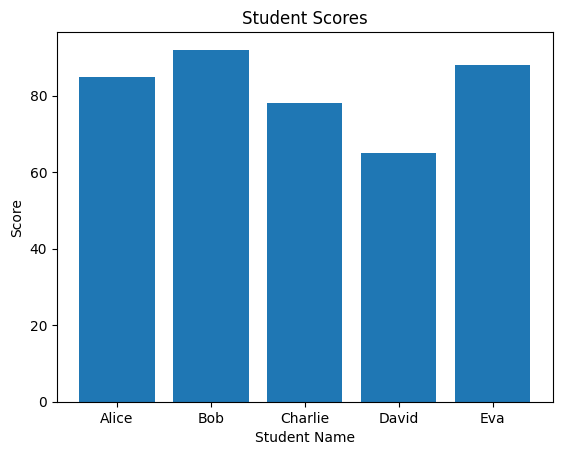

In [30]:
# The error occurred because 'StudyHours' and 'PreviousScore' are not in the DataFrame.
# Using available columns: 'Name' and 'Score'
plt.bar(df["Name"], df["Score"])
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.title("Student Scores")
plt.show()

Task 2: Preprocess Data

Step 1: Select Features and Target

In [31]:
# This will now work because the columns were added to the dataframe above
X = df[["StudyHours","Attendance","PreviousScore"]]
y = df["Pass"]

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   StudyHours  Attendance  PreviousScore
0          10          95             80
1          15         100             90
2           8          80             75
3           5          60             70
4          12          90             85

Target (y):
0    1
1    1
2    1
3    0
4    1
Name: Pass, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4
Test set size: 1


Step 2: Split Dataset

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 3: Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Task 3: Train ML Model

Step 1: Import Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

Step 2: Train Model

In [37]:
model = LogisticRegression()

model.fit(X_train,y_train)

print("Model Trained Successfully")

Model Trained Successfully


Step 3: Make Predictions

In [38]:
y_pred = model.predict(X_test)

print(y_pred)

[1]


Step 4: Check Accuracy

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 1.0


Step 5: Confusion Matrix

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Step 6: Classification Report

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



Step 7: Test with New Student

In [41]:
new_student = [[6,85,65]]

new_student = scaler.transform(new_student)

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Student Will Pass")
else:
    print("Student Will Fail")

Student Will Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
